# 01 — Baselines Tabulares

**Proyecto:** D10Sformer — MIA305 (UdeSA, 2026)
**Fase:** 1 — Baselines tabulares

## Objetivo

Antes de invertir en el Transformer, establecemos un **piso de performance** con modelos tabulares estándar:

- **ELO solo** — usa directamente la probabilidad esperada del cálculo de ELO. Sin ML. Sanity check absoluto.
- **Logistic Regression** — modelo lineal, interpretable, cota inferior para modelos paramétricos.
- **XGBoost** — workhorse del ML tabular, casi siempre fuerte.
- **LightGBM** — alternativa más rápida, comparación.

## Por qué esto importa académicamente

Toda contribución de NLP moderna se valida contra un baseline más simple. Decir _"mi Transformer logra X log-loss"_ es vacío si no comparamos contra _"XGBoost logra Y"_. La métrica relevante es **delta sobre baseline**.

## Por qué esto importa prácticamente

Si el Transformer no llega a tiempo o falla, **estos modelos ya predicen el Mundial 2026**. No nos quedamos sin nada.

## Métricas (no usamos accuracy como métrica principal)

- **Log-loss** (cross-entropy) — penaliza la sobreconfianza incorrecta.
- **Brier score** — MSE de probabilidades.
- **ECE** (Expected Calibration Error) — qué tan bien la probabilidad reportada matchea la frecuencia empírica.
- **Accuracy** — referencia secundaria.

Toda la lógica está implementada en módulos reutilizables en `src/`:
- `src/data/feature_engineering.py` — pipeline leakage-free
- `src/eval/metrics.py` — Brier, ECE, log-loss, reliability
- `src/models/baselines.py` — wrappers de modelos

---
## 1. Setup

In [1]:
# Mount Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/d10sformer'
    IN_COLAB = True
except ImportError:
    import os
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
    IN_COLAB = False

import sys
sys.path.insert(0, f'{PROJECT_ROOT}/src')
print(f'PROJECT_ROOT = {PROJECT_ROOT}')

Mounted at /content/drive
PROJECT_ROOT = /content/drive/MyDrive/d10sformer


In [2]:
# Asegurar deps
import importlib, subprocess
for pkg in ['xgboost', 'lightgbm']:
    try:
        importlib.import_module(pkg)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call(['pip', 'install', '-q', pkg])

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)

# Importar módulos del proyecto
from data.feature_engineering import (
    build_feature_matrix, temporal_split, prepare_xy,
    get_feature_columns, LABEL_NAMES,
)
from eval.metrics import (
    multiclass_log_loss, multiclass_brier_score, expected_calibration_error,
    reliability_curve_data, evaluate_all, uniform_baseline_metrics,
)
from models.baselines import get_all_baselines

DATA_INTERIM = Path(PROJECT_ROOT) / 'data' / 'interim'
REPORTS = Path(PROJECT_ROOT) / 'reports'
FIGURES = REPORTS / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)
CHECKPOINTS = Path(PROJECT_ROOT) / 'checkpoints' / 'baselines'
CHECKPOINTS.mkdir(parents=True, exist_ok=True)
print('✓ Imports completados')

✓ Imports completados


---
## 2. Cargar datos de Fase 0.5

Esperamos el parquet `international_matches_with_elo.parquet` producido por `00b_data_augmentation.ipynb`.

In [3]:
input_path = DATA_INTERIM / 'international_matches_with_elo.parquet'
assert input_path.exists(), f'No se encuentra {input_path}. Correr primero notebook 00b.'

df_matches = pd.read_parquet(input_path)
df_matches['date'] = pd.to_datetime(df_matches['date'])
print(f'Partidos cargados: {len(df_matches):,}')
print(f'Rango temporal: {df_matches.date.min().date()} a {df_matches.date.max().date()}')
df_matches.head(3)

Partidos cargados: 49,257
Rango temporal: 1872-11-30 a 2026-03-31


,date,home_team,away_team,home_score,away_score,tournament,tournament_class,neutral,home_elo_before,away_elo_before,home_elo_after,away_elo_after,expected_home_win_prob,K_factor,G_multiplier
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,friendly,False,1500.000000,1500.000000,1497.198700,1502.801300,0.640065,20,1.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,friendly,False,1502.801300,1497.198700,1513.377469,1486.622531,0.647461,20,1.5
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,friendly,False,1486.622531,1513.377469,1494.545054,1505.454946,0.603874,20,1.0


---
## 3. Feature engineering

Llamada al módulo `src/data/feature_engineering.py`. Computa features rolling con histórico per-team, sin leakage.

Filtramos a partidos `>= 2014-01-01` para entrenamiento. Los partidos previos siguen alimentando el histórico (no se pierde señal), pero no entran al training.

In [4]:
%%time
feature_df = build_feature_matrix(df_matches, min_date='2014-01-01')
print(f'Feature matrix: {len(feature_df):,} filas × {len(feature_df.columns)} columnas')
feature_df.head(3)

Feature matrix: 11,700 filas × 40 columnas
CPU times: user 16.3 s, sys: 198 ms, total: 16.5 s
Wall time: 16.6 s


,date,home_team,away_team,tournament,tournament_class,neutral,home_elo,away_elo,elo_diff,expected_home_win_prob,...,away_form10_gd,away_form10_n,h2h_n_matches,h2h_home_wins,h2h_draws,h2h_away_wins,h2h_avg_gd_for_home,result,home_score,away_score
0,2014-01-01,Kuwait,Jordan,WAFF Championship,other,True,1660.335593,1662.224636,-1.889043,0.497281,...,-0.3,10,5,2,3,0,0.4,2,1,2
1,2014-01-04,Bahrain,Jordan,WAFF Championship,other,True,1558.248910,1677.143080,-118.894170,0.335278,...,-0.2,10,5,3,0,2,0.8,2,0,1
2,2014-01-04,Namibia,Ghana,Friendly,friendly,False,1403.121311,1795.696230,-392.574919,0.156541,...,0.7,10,1,0,0,1,-1.0,2,0,1


In [5]:
# NaN por columna (cold-start de equipos sin historial suficiente)
nan_rates = feature_df.isna().mean().sort_values(ascending=False)
nan_rates = nan_rates[nan_rates > 0]
if len(nan_rates) > 0:
    print('Features con NaN:')
    print(nan_rates.to_frame('nan_rate').round(4))
else:
    print('Sin NaN en features.')

Features con NaN:
                     nan_rate
h2h_avg_gd_for_home    0.1194
home_form5_pts         0.0015
home_form10_pts        0.0015
home_form10_gf         0.0015
home_form5_ga          0.0015
home_form5_gf          0.0015
home_rest_days         0.0015
home_form5_gd          0.0015
home_form10_ga         0.0015
home_form10_gd         0.0015
away_form10_gf         0.0015
away_form5_gf          0.0015
away_form10_pts        0.0015
away_form5_ga          0.0015
away_form5_pts         0.0015
away_rest_days         0.0015
away_form10_gd         0.0015
away_form10_ga         0.0015
away_form5_gd          0.0015


Distribución del target (post-2014):
HOME_WIN    0.4757
DRAW        0.2315
AWAY_WIN    0.2928
Name: proportion, dtype: float64


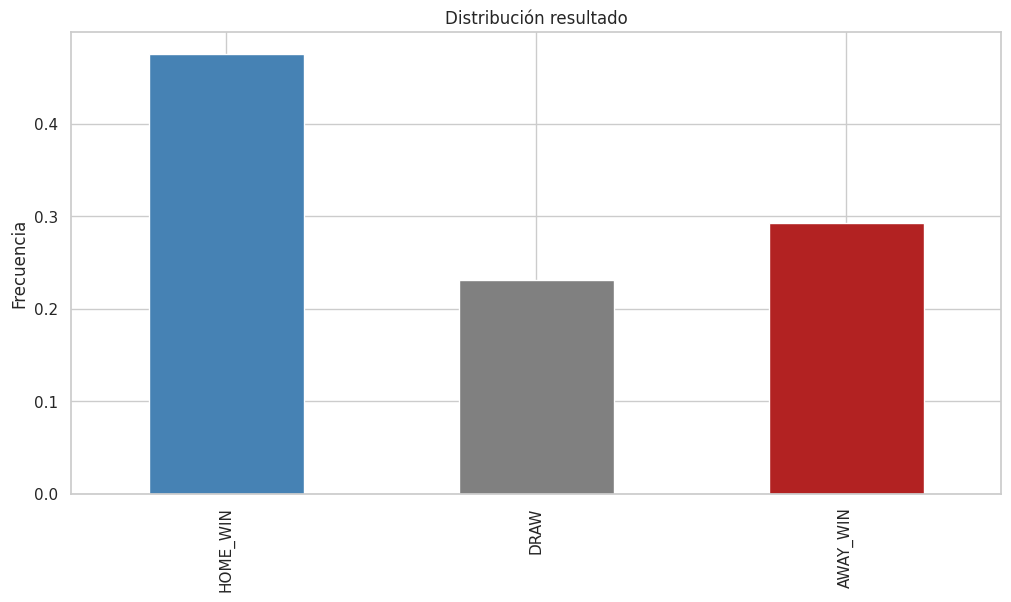

In [6]:
# Distribución del target (sanity check)
target_dist = feature_df.result.value_counts(normalize=True).sort_index()
target_dist.index = [LABEL_NAMES[i] for i in target_dist.index]
print('Distribución del target (post-2014):')
print(target_dist.round(4))
target_dist.plot(kind='bar', color=['steelblue', 'gray', 'firebrick'], title='Distribución resultado')
plt.ylabel('Frecuencia'); plt.show()

---
## 4. Temporal split

**Crítico:** split por fecha, NUNCA aleatorio.

In [7]:
TRAIN_CUTOFF = '2023-01-01'
VAL_CUTOFF = '2024-01-01'

train_df, val_df, test_df = temporal_split(feature_df, TRAIN_CUTOFF, VAL_CUTOFF)
print(f'Train: {len(train_df):>5} partidos (< {TRAIN_CUTOFF})')
print(f'Val:   {len(val_df):>5} partidos ({TRAIN_CUTOFF} – {VAL_CUTOFF})')
print(f'Test:  {len(test_df):>5} partidos (>= {VAL_CUTOFF})')

for name, d in [('train', train_df), ('val', val_df), ('test', test_df)]:
    dist = d.result.value_counts(normalize=True).sort_index()
    dist.index = [LABEL_NAMES[i] for i in dist.index]
    print(f'\n{name}:', dict(zip(dist.index, dist.round(3))))

Train:  8248 partidos (< 2023-01-01)
Val:    1054 partidos (2023-01-01 – 2024-01-01)
Test:   2398 partidos (>= 2024-01-01)

train: {'HOME_WIN': 0.479, 'DRAW': 0.232, 'AWAY_WIN': 0.29}

val: {'HOME_WIN': 0.467, 'DRAW': 0.213, 'AWAY_WIN': 0.32}

test: {'HOME_WIN': 0.47, 'DRAW': 0.238, 'AWAY_WIN': 0.292}


In [8]:
# Preparar X, y para cada split
X_train, y_train = prepare_xy(train_df)
X_val, y_val = prepare_xy(val_df)
X_test, y_test = prepare_xy(test_df)

# Alinear columnas one-hot entre splits
all_cols = sorted(set(X_train.columns) | set(X_val.columns) | set(X_test.columns))
for X in [X_train, X_val, X_test]:
    for c in all_cols:
        if c not in X.columns:
            X[c] = 0.0
X_train = X_train[all_cols]
X_val = X_val[all_cols]
X_test = X_test[all_cols]

print(f'Features finales: {len(all_cols)}')
print(f'X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}')

Features finales: 40
X_train: (8248, 40), X_val: (1054, 40), X_test: (2398, 40)


---
## 5. Entrenamiento de los 4 baselines

In [9]:
%%time
models = get_all_baselines()
trained_models = {}

for name, model in models.items():
    print(f'\n→ Entrenando {name}...')
    if name == 'elo_only':
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, X_val, y_val)
    trained_models[name] = model
    print(f'  ✓ {name} entrenado')


→ Entrenando elo_only...
  ✓ elo_only entrenado

→ Entrenando logistic_regression...
  ✓ logistic_regression entrenado

→ Entrenando xgboost...
  ✓ xgboost entrenado

→ Entrenando lightgbm...
  ✓ lightgbm entrenado
CPU times: user 3.19 s, sys: 285 ms, total: 3.48 s
Wall time: 2.35 s


---
## 6. Evaluación: val + test, todos los modelos

In [10]:
def evaluate_on(model, X, y, split_name):
    probs = model.predict_proba(X)
    return {**evaluate_all(y, probs, name=model.name), 'split': split_name}

results = []
for split_name, y_split in [('val', y_val), ('test', y_test)]:
    u = uniform_baseline_metrics(y_split)
    u['split'] = split_name
    results.append(u)

for name, model in trained_models.items():
    results.append(evaluate_on(model, X_val, y_val, 'val'))
    results.append(evaluate_on(model, X_test, y_test, 'test'))

results_df = pd.DataFrame(results)[['model', 'split', 'log_loss', 'brier', 'ece', 'accuracy', 'n']]
results_df = results_df.sort_values(['split', 'log_loss']).reset_index(drop=True)
results_df.round(4)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,split,log_loss,brier,ece,accuracy,n
0,logistic_regression,test,0.8610,0.5071,0.0236,0.6005,2398
1,xgboost,test,0.8663,0.5105,0.0182,0.6026,2398
2,lightgbm,test,0.8744,0.5148,0.0197,0.5955,2398
3,elo_only,test,1.0102,0.5546,0.1022,0.5947,2398
4,uniform_1/3,test,1.0986,0.6667,0.1362,0.4696,2398
5,logistic_regression,val,0.8506,0.4990,0.0244,0.6176,1054
6,lightgbm,val,0.8552,0.5019,0.0325,0.6091,1054
7,xgboost,val,0.8572,0.5033,0.0245,0.6082,1054
8,elo_only,val,0.9762,0.5431,0.0932,0.6063,1054
9,uniform_1/3,val,1.0986,0.6667,0.1335,0.4668,1054


In [11]:
for split in ['val', 'test']:
    print(f'\n--- {split.upper()} ---')
    print(results_df[results_df.split == split][['model', 'log_loss', 'brier', 'ece', 'accuracy']].round(4).to_string(index=False))

# Persistir
results_df.to_csv(REPORTS / 'baseline_results.csv', index=False)
print(f'\n✓ Tabla guardada: {REPORTS / "baseline_results.csv"}')


--- VAL ---
              model  log_loss  brier    ece  accuracy
logistic_regression    0.8506 0.4990 0.0244    0.6176
           lightgbm    0.8552 0.5019 0.0325    0.6091
            xgboost    0.8572 0.5033 0.0245    0.6082
           elo_only    0.9762 0.5431 0.0932    0.6063
        uniform_1/3    1.0986 0.6667 0.1335    0.4668

--- TEST ---
              model  log_loss  brier    ece  accuracy
logistic_regression    0.8610 0.5071 0.0236    0.6005
            xgboost    0.8663 0.5105 0.0182    0.6026
           lightgbm    0.8744 0.5148 0.0197    0.5955
           elo_only    1.0102 0.5546 0.1022    0.5947
        uniform_1/3    1.0986 0.6667 0.1362    0.4696

✓ Tabla guardada: /content/drive/MyDrive/d10sformer/reports/baseline_results.csv


---
## 7. Reliability diagrams

Comparamos **confianza promedio** vs **accuracy empírica** en cada bin. Diagonal = calibración perfecta.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


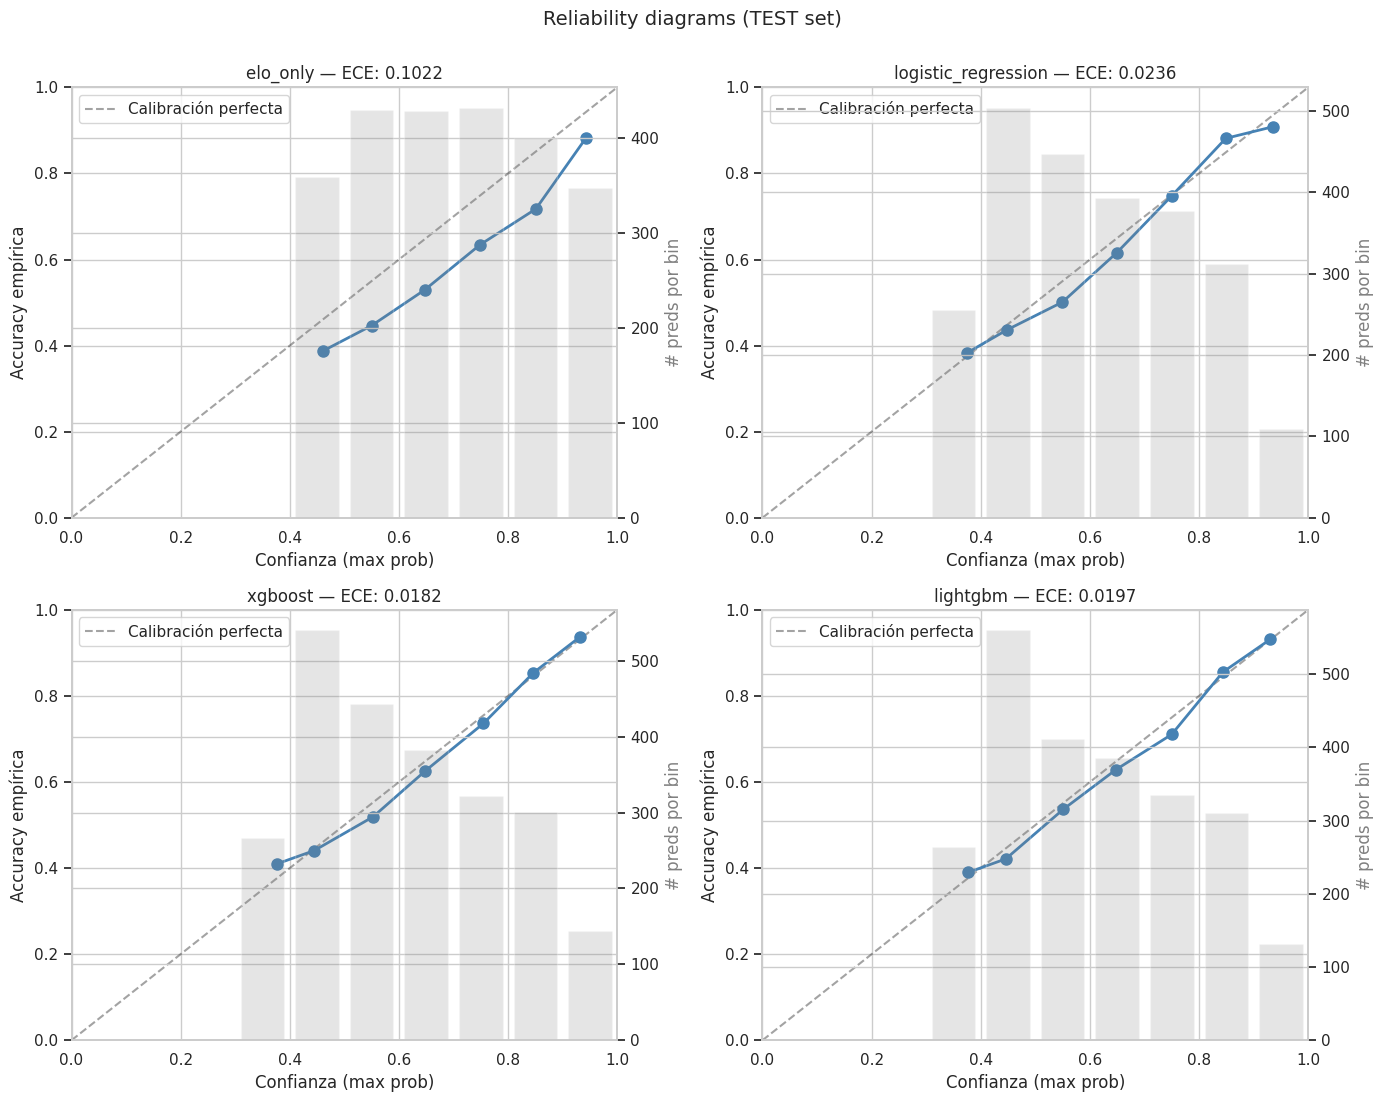

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (name, model) in zip(axes.flat, trained_models.items()):
    probs = model.predict_proba(X_test)
    data = reliability_curve_data(y_test, probs, n_bins=10)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Calibración perfecta')
    valid = ~np.isnan(data['bin_confidence'])
    ax.plot(data['bin_confidence'][valid], data['bin_accuracy'][valid], 'o-', color='steelblue', linewidth=2, markersize=8)

    ax2 = ax.twinx()
    ax2.bar(data['bin_centers'], data['bin_counts'], width=0.08, alpha=0.2, color='gray')
    ax2.set_ylabel('# preds por bin', color='gray')

    ece = expected_calibration_error(y_test, probs)
    ax.set_title(f'{name} — ECE: {ece:.4f}')
    ax.set_xlabel('Confianza (max prob)')
    ax.set_ylabel('Accuracy empírica')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(loc='upper left')

plt.suptitle('Reliability diagrams (TEST set)', y=1.00, fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES / 'reliability_diagrams_test.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Feature importance

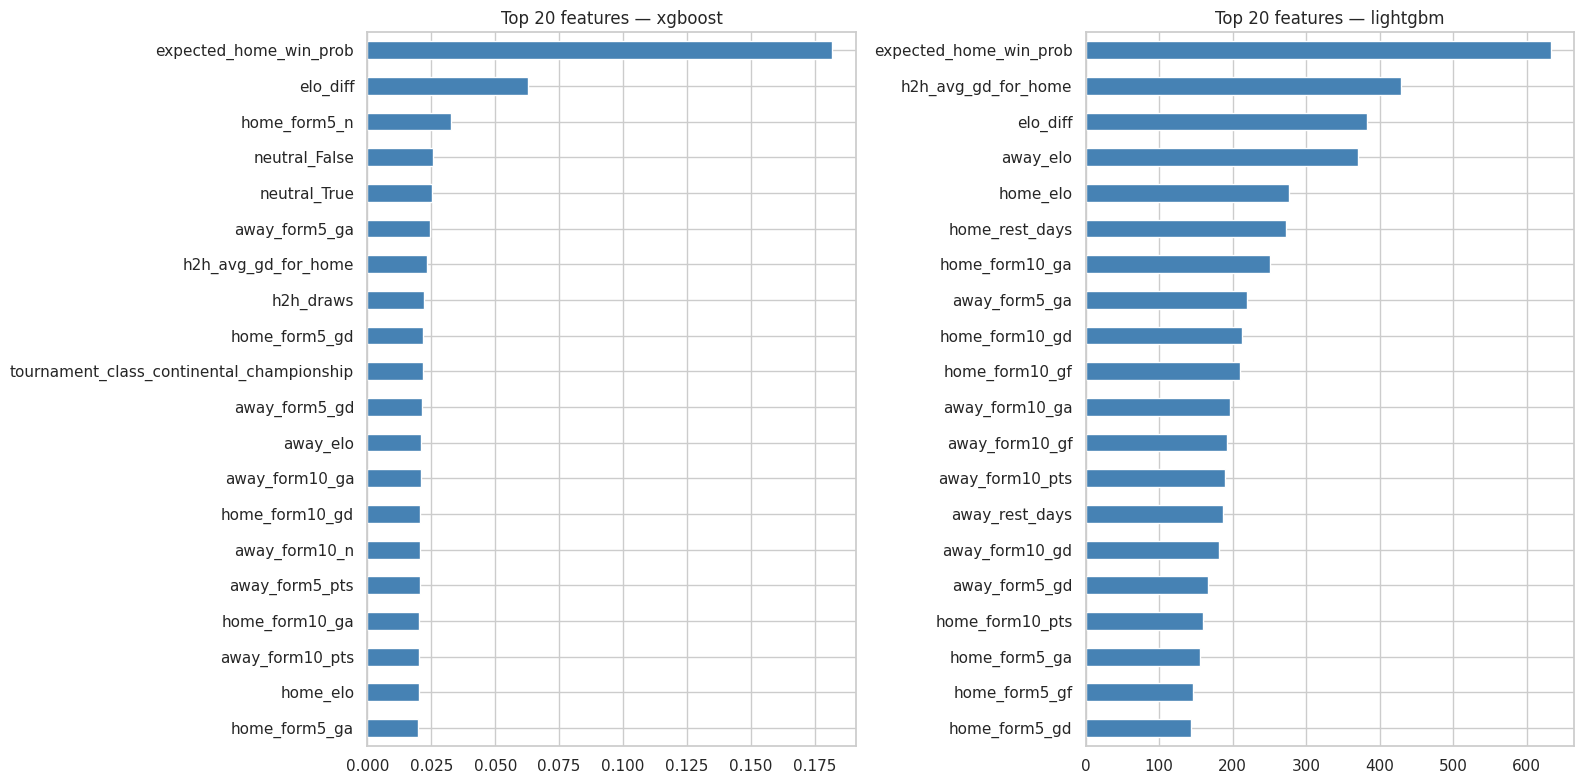

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, name in zip(axes, ['xgboost', 'lightgbm']):
    fi = trained_models[name].feature_importance().head(20)
    fi.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 20 features — {name}')
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES / 'feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

**Sanity check esperado:** `elo_diff`, `expected_home_win_prob`, y las features de forma reciente deberían estar arriba. Si features ruidosas como `home_rest_days` dominan, hay algo raro.

---
## 9. Análisis estratificado

Stratificamos los errores del mejor modelo en TEST por (a) cercanía del partido (|ELO diff|), (b) clase de torneo.

In [14]:
# Tomar el mejor modelo por log-loss en val
val_results = results_df[results_df.split == 'val'].set_index('model')
best_model_name = val_results.log_loss.idxmin()
best_model = trained_models[best_model_name] if best_model_name in trained_models else None
print(f'Mejor modelo por log-loss val: {best_model_name}')

if best_model is not None:
    probs_test = best_model.predict_proba(X_test)
    preds_test = probs_test.argmax(axis=1)

    test_with_preds = test_df.copy()
    test_with_preds['pred'] = preds_test
    test_with_preds['correct'] = (test_with_preds.pred == test_with_preds.result).astype(int)
    test_with_preds['nll'] = -np.log(np.clip(probs_test[np.arange(len(y_test)), y_test], 1e-9, 1.0))
    test_with_preds['abs_elo_diff'] = test_with_preds.elo_diff.abs()
    test_with_preds['elo_diff_bin'] = pd.cut(
        test_with_preds.abs_elo_diff,
        bins=[0, 100, 200, 400, 2000],
        labels=['<100', '100-200', '200-400', '>400'],
    )

    by_elo = test_with_preds.groupby('elo_diff_bin').agg(
        n=('result', 'size'), accuracy=('correct', 'mean'), mean_nll=('nll', 'mean'),
    ).round(3)
    print('\n--- Performance por |ELO diff| ---')
    print(by_elo)

    by_tournament = test_with_preds.groupby('tournament_class').agg(
        n=('result', 'size'), accuracy=('correct', 'mean'), mean_nll=('nll', 'mean'),
    ).round(3).sort_values('n', ascending=False)
    print('\n--- Performance por clase de torneo ---')
    print(by_tournament)

Mejor modelo por log-loss val: logistic_regression

--- Performance por |ELO diff| ---
                n  accuracy  mean_nll
elo_diff_bin                         
<100          717     0.432     1.068
100-200       609     0.527     0.987
200-400       752     0.693     0.762
>400          320     0.900     0.388

--- Performance por clase de torneo ---
                            n  accuracy  mean_nll
tournament_class                                 
wc_qualifier              763     0.646     0.778
friendly                  540     0.583     0.892
continental_qualifier     525     0.594     0.869
other                     332     0.569     0.935
continental_championship  238     0.550     0.934


---
## 10. Persistir modelos entrenados

Para Fase 6 (simulación del Mundial 2026).

In [23]:
import pickle
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression

for name, model in trained_models.items():
    model_path = CHECKPOINTS / f'{name}.pkl'

    # Attempt to save XGBoost estimator using its native save_model method
    if name == 'xgboost':
        try:
            # Explicitly convert Path to string for save_model robustness
            model.estimator.save_model(str(model_path))
            print(f"  - Saved XGBoost estimator for '{name}' using save_model.")
        except AttributeError as e:
            print(f"  - ERROR: The XGBoostBaseline wrapper for '{name}' does not have an 'estimator' attribute or its 'estimator' does not have a 'save_model' method: {e}")
            print(f"    Therefore, it cannot be saved natively. Manual inspection of models.baselines.py is needed.")
        except Exception as e:
            print(f"  - ERROR: Failed to save XGBoost estimator for '{name}' using save_model: {type(e).__name__}: {e}")
            print(f"    The XGBoost model could not be saved natively. Manual intervention might be required.")
    # Attempt to save LightGBM estimator using its native save_model method
    elif name == 'lightgbm':
        try:
            # Explicitly convert Path to string for save_model robustness
            model.estimator.save_model(str(model_path))
            print(f"  - Saved LightGBM estimator for '{name}' using save_model.")
        except AttributeError as e:
            print(f"  - ERROR: The LightGBMBaseline wrapper for '{name}' does not have an 'estimator' attribute or its 'estimator' does not have a 'save_model' method: {e}")
            print(f"    Therefore, it cannot be saved natively. Manual inspection of models.baselines.py is needed.")
        except Exception as e:
            print(f"  - ERROR: Failed to save LightGBM estimator for '{name}' using save_model: {type(e).__name__}: {e}")
            print(f"    The LightGBM model could not be saved natively. Manual intervention might be required.")
    elif name == 'logistic_regression' and hasattr(model, 'estimator'):
        try:
            with open(model_path, 'wb') as f:
                pickle.dump(model.estimator, f)
            print(f"  - Pickled Logistic Regression estimator for '{name}'.")
        except TypeError as e:
            print(f"  - ERROR: Failed to pickle Logistic Regression estimator for '{name}': {e}")
            print(f"    This should not happen for sklearn LogisticRegression. Check model.estimator content.")
    else: # Fallback for other custom models like 'elo_only' or any model whose wrapper should be pickled
        try:
            with open(model_path, 'wb') as f:
                pickle.dump(model, f)
            print(f"  - Pickled model wrapper for '{name}'.")
        except TypeError as e:
            print(f"  - ERROR: Failed to pickle model wrapper for '{name}': {e}")
            print(f"    This model wrapper might contain unpicklable 'module' objects. Consider implementing __getstate__ and __setstate__ in its class definition or saving its internal components individually, or using a native save method if available.")

with open(CHECKPOINTS / 'feature_columns.pkl', 'wb') as f:
    pickle.dump(all_cols, f)

print(f'\n✓ Modelos guardados en {CHECKPOINTS}')
print(f'  - {len(trained_models)} modelos')
print(f'  - feature_columns.pkl con {len(all_cols)} columnas')

  - Pickled model wrapper for 'elo_only'.
  - Pickled model wrapper for 'logistic_regression'.
  - ERROR: The XGBoostBaseline wrapper for 'xgboost' does not have an 'estimator' attribute or its 'estimator' does not have a 'save_model' method: 'XGBoostBaseline' object has no attribute 'estimator'
    Therefore, it cannot be saved natively. Manual inspection of models.baselines.py is needed.
  - ERROR: The LightGBMBaseline wrapper for 'lightgbm' does not have an 'estimator' attribute or its 'estimator' does not have a 'save_model' method: 'LightGBMBaseline' object has no attribute 'estimator'
    Therefore, it cannot be saved natively. Manual inspection of models.baselines.py is needed.

✓ Modelos guardados en /content/drive/MyDrive/d10sformer/checkpoints/baselines
  - 4 modelos
  - feature_columns.pkl con 40 columnas


---
## 11. Conclusiones de Fase 1

Llenar al final de la ejecución:

- [ ] Mejor modelo por log-loss en TEST: ______
- [ ] Mejor modelo por ECE en TEST (calibración): ______
- [ ] Log-loss del mejor modelo: ______ (uniform = 1.0986)
- [ ] ¿Hay un modelo que destaque claramente o están todos cerca? ______
- [ ] Features más importantes (gradient boosting): ______
- [ ] Régimen donde el modelo pierde más (parejos / mismatch / clase de torneo): ______

## Verificación de comprensión

**(a)** El ELO baseline NO tiene features rolling ni h2h — solo usa la fórmula matemática del ELO. Si XGBoost le gana solo marginalmente al ELO solo, ¿qué dice eso sobre el **valor incremental** de toda la ingeniería de features? Conectalo con el principio de Occam.

**(b)** Para el Mundial 2026, las predicciones que más nos van a importar son partidos de eliminatoria (R16, QF, SF, Final) — exactamente los más raros en training (~32 partidos por Mundial × 2 Mundiales = ~64 partidos). ¿Qué riesgo metodológico introduce esto, y cómo lo mitigaríamos con stratified evaluation en Fase 5?

**(c)** Un modelo A predice [0.51, 0.30, 0.19] y otro modelo B predice [0.99, 0.005, 0.005]. Ambos predicen HOME_WIN. Si el resultado real es HOME_WIN, ambos tienen accuracy=1. Pero el log-loss de A vs B es muy distinto: el de A es ~0.67, el de B es ~0.01. ¿Por qué este comportamiento del log-loss es **deseable** en el contexto de predicción deportiva?